In [1]:
#Classificação binária
#g(xi) ≈ yi
# y e {0, 1}
#a saída do modelo é uma pontuação entre 0 - 1, que é a probabilidade do cliente cancelar
#As informações que temos sobre os clientes são o X

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [3]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [4]:
!wget $data -O data.csv 

--2026-08-01 21:46:51--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 977501 (955K) [text/plain]
Saving to: ‘data.csv’

data.csv            100%[===================>] 954.59K  --.-KB/s    in 0.02s   

2026-08-01 21:46:51 (39.7 MB/s) - ‘data.csv’ saved [977501/977501]



In [5]:
df = pd.read_csv('data.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.head().T #Transpõe o DataFrame, linhas viram colunas

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [7]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

In [8]:
df.head().T

,0,1,2,3,4
customerid,7590-vhveg,5575-gnvde,3668-qpybk,7795-cfocw,9237-hqitu
gender,female,male,male,male,female
seniorcitizen,0,0,0,0,0
partner,yes,no,no,no,no
dependents,no,no,no,no,no
tenure,1,34,2,45,2
phoneservice,no,yes,yes,no,yes
multiplelines,no_phone_service,no,no,no_phone_service,no
internetservice,dsl,dsl,dsl,dsl,fiber_optic
onlinesecurity,no,yes,yes,yes,no


In [9]:
df.dtypes

customerid           object
gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges         object
churn                object
dtype: object

In [10]:
tc = pd.to_numeric(df.totalcharges, errors = 'coerce')

In [11]:
df.totalcharges = pd.to_numeric(df.totalcharges, errors = 'coerce')

In [12]:
df.totalcharges = df.totalcharges.fillna(0)

In [13]:
df[tc.isnull()][['customerid', 'totalcharges']]

,customerid,totalcharges
488,4472-lvygi,0.0
753,3115-czmzd,0.0
936,5709-lvoeq,0.0
1082,4367-nuyao,0.0
1340,1371-dwpaz,0.0
3331,7644-omvmy,0.0
3826,3213-vvolg,0.0
4380,2520-sgtta,0.0
5218,2923-arzlg,0.0
6670,4075-wkniu,0.0


In [14]:
df.churn = (df.churn == 'yes').astype(int)

In [15]:
#Configurando a estrutura de validação

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
df_full_train, df_test = train_test_split(df, test_size = 0.2, random_state = 1)

In [18]:
len(df_test), len(df_full_train)

(1409, 5634)

In [19]:
df_train, df_val = train_test_split(df_full_train, test_size = 0.25, random_state = 1)

In [20]:
len(df_train), len(df_val)

(4225, 1409)

In [21]:
df_train = df_train.reset_index(drop = True)
df_val = df_val.reset_index(drop = True)
df_test = df_test.reset_index(drop = True)

In [22]:
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

In [23]:
del df_train['churn']
del df_val['churn']
del df_test['churn']

In [24]:
#Análise exploratória de dados

In [25]:
df_full_train = df_full_train.reset_index(drop = True)

In [26]:
df_full_train.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [27]:
df_full_train.churn.value_counts(normalize = True)
#1 = Taxa de usuários que cancelam

churn
0    0.730032
1    0.269968
Name: proportion, dtype: float64

In [28]:
global_churn_rate = df_full_train.churn.mean()
round(global_churn_rate, 2)

np.float64(0.27)

In [29]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

In [30]:
df_full_train.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

In [31]:
categorical = ['gender', 'seniorcitizen', 'partner', 'dependents',
        'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod']

In [32]:
df_full_train[categorical]

,gender,seniorcitizen,partner,dependents,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod
0,male,0,yes,yes,yes,no,no,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check
1,female,0,no,no,yes,no,dsl,yes,yes,yes,yes,no,yes,one_year,no,credit_card_(automatic)
2,male,0,yes,no,yes,yes,dsl,yes,yes,no,yes,no,no,two_year,no,bank_transfer_(automatic)
3,male,0,yes,yes,yes,yes,dsl,yes,no,yes,yes,yes,yes,one_year,no,electronic_check
4,male,0,no,no,yes,no,dsl,yes,yes,no,yes,yes,no,one_year,no,electronic_check
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,male,1,no,no,yes,yes,fiber_optic,no,no,yes,no,yes,yes,month-to-month,yes,electronic_check
5630,male,0,no,yes,yes,no,no,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check
5631,male,0,no,no,yes,yes,fiber_optic,no,yes,yes,no,yes,yes,month-to-month,yes,electronic_check
5632,male,0,no,no,yes,yes,dsl,no,yes,no,no,no,no,month-to-month,yes,mailed_check


In [33]:
#Taxa de rotatividade em cada grupo

In [34]:
churn_female = df_full_train[df_full_train.gender == 'female'].churn.mean()
churn_female

np.float64(0.27682403433476394)

In [35]:
churn_male = df_full_train[df_full_train.gender == 'male'].churn.mean()
churn_male

np.float64(0.2632135306553911)

In [36]:
global_churn = df_full_train.churn.mean()
global_churn

np.float64(0.26996805111821087)

In [37]:
df_full_train.partner.value_counts()

partner
no     2932
yes    2702
Name: count, dtype: int64

In [38]:
churn_no_partner = df_full_train[df_full_train.partner == 'no'].churn.mean()
churn_no_partner

np.float64(0.3298090040927694)

In [39]:
churn_partner = df_full_train[df_full_train.partner == 'yes'].churn.mean()
churn_partner

np.float64(0.20503330866025166)

In [40]:
#Comparando variáveis conseguimos medir a importância do treinamento, então podemos observar a diferença
#Se comparamos a diferença entre a taxa de cancelamento global com a de um grupo e for maior que zero.
#Significa que se essa diferença for maior que zero a taxa de cancelamento global é maior e significa que esse grupo tem menos chance de cancelar
#Caso a diferença for negativa significa que esse grupo tem maior probabilidade de cancelar.
#Estamos interessados em diferenças maiores
#Ao invés de analisar podemos dividir uma pela outra.

In [41]:
churn_no_partner / global_churn 

np.float64(1.2216593879412643)

In [42]:
churn_partner / global_churn

np.float64(0.7594724924338315)

In [43]:
#Com esses resutlado percebemos que pessoas sem parceiros parecem ter maior probabilidade de cancelar.
#Pois diferença > 1

In [44]:
#Outra métrica importante é a razão de risco
#Nesse caso o risco é calculado dividindo-se a taxa de cancelamento do grupo pela global

In [45]:
#A taxa de rotatividade é dividida pela taxa de rotatividade global se > 1.
#A probabilidade de cancelamento é maior
#Se < 1, é menor

In [46]:
#Assim conseguimos ter uma intuição de qual variável é importante e de cada subgrupo que essa variável define

In [47]:
from IPython.display import display

In [48]:
for c in categorical:
    print(c)
    df_group = df_full_train.groupby(c).churn.agg(['mean', 'count'])
    df_group['diff'] = df_group['mean'] - global_churn
    df_group['risk'] = df_group['mean'] / global_churn
    display(df_group)
    print()
    print()

#Comparação variável por variável, para acharmos as mais importantes

gender


,mean,count,diff,risk
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980




seniorcitizen


,mean,count,diff,risk
seniorcitizen,,,,
0,0.242270,4722,-0.027698,0.897403
1,0.413377,912,0.143409,1.531208




partner


...

,mean,count,diff,risk
contract,,,,
month-to-month,0.431701,3104,0.161733,1.599082
one_year,0.120573,1186,-0.149395,0.446621
two_year,0.028274,1344,-0.241694,0.104730




paperlessbilling


,mean,count,diff,risk
paperlessbilling,,,,
no,0.172071,2313,-0.097897,0.637375
yes,0.338151,3321,0.068183,1.252560




paymentmethod


,mean,count,diff,risk
paymentmethod,,,,
bank_transfer_(automatic),0.168171,1219,-0.101797,0.622928
credit_card_(automatic),0.164339,1217,-0.105630,0.608733
electronic_check,0.455890,1893,0.185922,1.688682
mailed_check,0.193870,1305,-0.076098,0.718121


In [49]:
#Informação mútua -> forma de medir a importância de variáveis categóricas.

In [50]:
#Ele da a importância de cada variável
# Ela quantifica a quantidade de informações que obtemos sobre uma variável por outra, observando outra variável
#I(X,Y) = Dkl(P(x,y) || Px * Py)

In [51]:
from sklearn.metrics import mutual_info_score

In [52]:
mutual_info_score(df_full_train.contract, df_full_train.churn)

0.0983203874041556

In [53]:
mutual_info_score(df_full_train.gender, df_full_train.churn)

0.0001174846211139946

In [54]:
mutual_info_score(df_full_train.partner, df_full_train.churn)

0.009967689095399745

In [55]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_full_train.churn)

In [56]:
mi = df_full_train[categorical].apply(mutual_info_churn_score)
mi.sort_values(ascending = False)

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

In [57]:
#Correlação, forma de medir a importância futura de variáveis

In [58]:
#Mede o grau de dependência entre duas variáveis
#É definido por r, no intervalo de [-1, 1]
#Em correlações negativas, se os valores de x sobem, o de y desce e visce-versa
#Em correlações positias, se uma variável aumenta a outra também aumenta
#Se entre 0,0 - 0,1 ou 0,0 - -0,1 -> A correlacao é quase inexistente
#Entre -0.2 - -0.5 ou 0.2 - 0.5 -> A correlação é moderada, aumento de uma variável as vezes leva ao aumento da outra
#De -0.6 - -1.0 ou 0.6 - 1.0 -> Correlações muito fortes, quase sempre ou aumento de uma leva o aumento da outra, ou vice-versa diminuindo

In [59]:
#Tornando mensurável, 
#X sendo o número de meses que o cliente esta na empresa, 0 - 72
#Y o churn {0,1}
#Quanto mais X aumenta(estabilidade no cargo), maior sera o churn, mais rotatividade
#Na correlação negativa significa que quanto maior tempo de permanência no cargo, menor rotatividade
#E correlação zero ou relação local, significa que a variável não afeta a taxa de rotatividade 

In [60]:
df_full_train[numerical].corrwith(df_full_train.churn).abs()

tenure            0.351885
monthlycharges    0.196805
totalcharges      0.196353
dtype: float64

In [61]:
#Por ser negativo, quanto maior a permanência, menor a probabilidade de churn
#O mesmo de tenure, ocorre em total charges, quanto mais as pessoas pagam, menor a probabilidade de cancelarem
#Nas cobranças mensais, quanto maior as cobranças mensais, maior a taxa de churn

In [62]:
df_full_train[df_full_train.tenure <= 2].churn.mean()

np.float64(0.5953420669577875)

In [63]:
df_full_train[(df_full_train.tenure > 2) & (df_full_train.tenure <= 12)].churn.mean()

np.float64(0.3994413407821229)

In [64]:
df_full_train[df_full_train.tenure > 12].churn.mean()

np.float64(0.17634908339788277)

In [65]:
df_full_train[df_full_train.monthlycharges <= 20].churn.mean()

np.float64(0.08795411089866156)

In [66]:
df_full_train[(df_full_train.monthlycharges > 20) & (df_full_train.monthlycharges <= 50)].churn.mean()

np.float64(0.18340943683409436)

In [67]:
df_full_train[df_full_train.monthlycharges > 50].churn.mean()

np.float64(0.32499341585462205)

In [68]:
#Codificação de variáveis categóricas

In [69]:
#One-hot-encoding

In [70]:
#Exemplo
#Temos a variável de gênero e outra de tempo de contrato
#E temos as observações: [(F, 2Y); (F, 1Y); (M, 1M)]
#O one hot encoding codifica essas variáveis
#Temos 2 variaveis para genero e 3 para o tempo de contrato.
#Criamos uma matriz com o a caracteristica, o número de variaveis e a preenchemos com números binários, 1 quando existe e 0 quando não

In [71]:
from sklearn.feature_extraction import DictVectorizer

In [72]:
train_dicts = df_train[categorical + numerical].iloc[:100].to_dict(orient = 'records')

In [73]:
dv = DictVectorizer(sparse = False)

In [74]:
X_train = dv.fit_transform(train_dicts)

In [75]:
val_dicts = df_val[categorical + numerical].iloc[:100].to_dict(orient = 'records')

In [76]:
X_val = dv.transform(val_dicts)

In [77]:
#Regressão logística

In [78]:
#g(xi) ≈ yi -> classificação binária

In [79]:
#yi = {0,1}, 0 negativos e 1 positivos
#no ex, churn = 1 e no churn = 0
#O output do modelo g(xi) é um número no intervalo 0 - 1, probabilidade de xi se tornar uma classe positiva
#g(xi) = w0 + wˆtxi, com o resultado um intervalo entre zero e um

In [80]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [81]:
z = np.linspace(-7, 7, 51)
z

array([-5. , -4.8, -4.6, -4.4, -4.2, -4. , -3.8, -3.6, -3.4, -3.2, -3. ,
       -2.8, -2.6, -2.4, -2.2, -2. , -1.8, -1.6, -1.4, -1.2, -1. , -0.8,
       -0.6, -0.4, -0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2,  1.4,
        1.6,  1.8,  2. ,  2.2,  2.4,  2.6,  2.8,  3. ,  3.2,  3.4,  3.6,
        3.8,  4. ,  4.2,  4.4,  4.6,  4.8,  5. ])

In [82]:
sigmoid(z)

array([0.00669285, 0.00816257, 0.0099518 , 0.01212843, 0.01477403,
       0.01798621, 0.02188127, 0.02659699, 0.03229546, 0.03916572,
       0.04742587, 0.05732418, 0.06913842, 0.0831727 , 0.09975049,
       0.11920292, 0.14185106, 0.16798161, 0.19781611, 0.23147522,
       0.26894142, 0.31002552, 0.35434369, 0.40131234, 0.450166  ,
       0.5       , 0.549834  , 0.59868766, 0.64565631, 0.68997448,
       0.73105858, 0.76852478, 0.80218389, 0.83201839, 0.85814894,
       0.88079708, 0.90024951, 0.9168273 , 0.93086158, 0.94267582,
       0.95257413, 0.96083428, 0.96770454, 0.97340301, 0.97811873,
       0.98201379, 0.98522597, 0.98787157, 0.9900482 , 0.99183743,
       0.99330715])

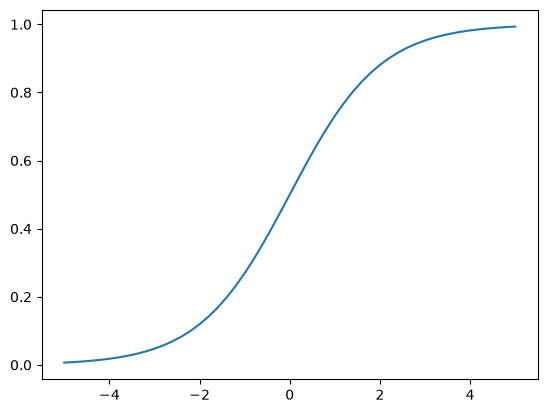

In [83]:
plt.plot(z, sigmoid(z))

In [85]:
def linear_regression(xi):
    result = w0

    for j in range(len(x)):
        result = result + xi[j] * w[j]

    return result

In [86]:
def logistic_regression(xi):
    score = w0

    for j in range(len(x)):
        result = result + xi[j] * w[j]

    result = sigmoid(score)
    return result

In [87]:
#Treinando o modelo com regressão logística

In [88]:
from sklearn.linear_model import LogisticRegression

In [90]:
model = LogisticRegression()
model.fit(X_train, y_train)

ValueError: Found input variables with inconsistent numbers of samples: [100, 4225]